## Baseline scripts for analyzing output from qpixrtd

output ROOT files from qpixrtd are similar to those found within radiogenic data with additional generator particle information.

These data are created from GENIE output files based on neutrino interactions.
As such, the extraction process is similar to that of radiogenicNB except that additional branches are
stored in the output ROOT files within the scripts directory.

Additionally, the entries within the ROOT files for neutrios represent entire events.
Therefore, the output of these files should store the entire events themselves and when a set of simulated resets are created, only a single event should be read in.

The output reset files will be separated based on input ParticleDataGroup (PDG) identification number.

In [1]:
import ROOT
import os
import sys
import numpy as np

# place to look for the filtered root data files
outputdir = "./scripts/v_output_data"
isDir = os.path.isdir(outputdir)
assert isDir, "need to have an output directory to read the filter data from!"

ROOT.EnableImplicitMT()
ROOT.gInterpreter.GenerateDictionary("ROOT::VecOps::RVec<vector<double>>", "vector;ROOT/RVec.hxx")
ROOT.gInterpreter.GenerateDictionary("ROOT::VecOps::RVec<vector<int>>", "vector;ROOT/RVec.hxx")


Welcome to JupyROOT 6.27/01


1

### specify columns of interest for input and output ROOT files.

In [2]:
# output RDF columns which are required for digital sim
data_columns = [
    "pixel_x",
    "pixel_y",
    "pixel_reset"
    ]

# columns which do not have repeating indices but we want to store in output RDF
filter_columns = [
    "run",                                 # determines name of input GENIE file
    "event",                               # filters for each output file
    "generator_initial_number_particles",  # number of inital input particles from GENIE
    # vectors of input particles, but 0 index is the lepton we care about
    "generator_initial_particle_pdg_code", # useful for input particle
    "generator_initial_particle_energy",   # incoming muon energy
    "generator_initial_particle_charge",   # inital lepton data below
    "generator_initial_particle_energy",
    "generator_initial_particle_mass",
    "generator_initial_particle_px", 
    "generator_initial_particle_py",
    "generator_initial_particle_pz",
    "generator_initial_particle_t",
    "generator_initial_particle_x", 
    "generator_initial_particle_y",
    "generator_initial_particle_z",
]

# all columns from input RTD.root files
all_columns = [
    "energy_deposit", "event", "generator_final_number_particles",
    "generator_final_particle_charge", "generator_final_particle_energy",
    "generator_final_particle_mass", "generator_final_particle_pdg_code",
    "generator_final_particle_px", "generator_final_particle_py",
    "generator_final_particle_pz", "generator_final_particle_t",
    "generator_final_particle_x", "generator_final_particle_y",
    "generator_final_particle_z", "generator_initial_number_particles",
    "generator_initial_particle_charge", "generator_initial_particle_energy",
    "generator_initial_particle_mass", "generator_initial_particle_pdg_code",
    "generator_initial_particle_px", "generator_initial_particle_py",
    "generator_initial_particle_pz", "generator_initial_particle_t",
    "generator_initial_particle_x", "generator_initial_particle_y",
    "generator_initial_particle_z", "hit_end_t", "hit_end_x", "hit_end_y",
    "hit_end_z", "hit_energy_deposit", "hit_length", "hit_process_key",
    "hit_start_t", "hit_start_x", "hit_start_y", "hit_start_z", "hit_track_id",
    "number_hits", "number_particles", "particle_charge",
    "particle_daughter_track_id", "particle_initial_energy", "particle_initial_px",
    "particle_initial_py", "particle_initial_pz", "particle_initial_t",
    "particle_initial_x", "particle_initial_y", "particle_initial_z",
    "particle_mass", "particle_number_daughters", "particle_parent_track_id",
    "particle_pdg_code", "particle_process_key", "particle_total_occupancy",
    "particle_track_id", "pixel_reset", "pixel_reset_truth_track_id",
    "pixel_reset_truth_weight", "pixel_tslr", "pixel_x", "pixel_y"
    ]

### Helper functions to read neutrino ROOT Files

much of this code is similar to that found in radiogenicNB, except that the ROOT files themselves encode which
particles generated these resets.

In [3]:
def getRDF(filePath, type=""):
    """
    this function should walk the neutrinos directory and spit back the file path
    of all ROOT files:
    """

    files = []
    for rs, ds, fs in os.walk(filePath):
        f = [f for f in fs if "root" in f and "RTD" in f]
        if f:
            f = [os.path.join(rs, f) for f in f ]
            files.extend(f)

    rdf = ROOT.RDataFrame("event_tree", f)
    return rdf
    

In [4]:
def constructRDF(data, evt, fcols=filter_columns, dcols=data_columns):
    """
    Helper function which constructs the RDF from a filtered
    total input RDF based on the run and event

    data is numpy input from filtered RDF.

    returns dict to construct rdf from
    """
    # every event needs its own rdf to make a tfile
    dict_e = {}

    # data columns of pixel resets are jagged array of pixel to resets
    nResets = 0
    for pr in data["pixel_reset"][evt]:
        nResets += pr.size()

    npResets = np.zeros(nResets)
    npX = np.zeros(nResets)
    npY = np.zeros(nResets)

    entry = 0
    for pr, x, y in zip(data["pixel_reset"][evt], data["pixel_x"][evt], data["pixel_y"][evt]):
        for r in pr:
            npResets[entry] = r
            npX[entry] = x
            npY[entry] = y
            entry += 1

    dict_e["pixel_reset"] = npResets
    dict_e["pixel_x"] = npX
    dict_e["pixel_y"] = npY

    # meta data columns need to be extended of flattened arrays to this
    for k in fcols:
        rcol = data[k][evt]
        if np.isscalar(rcol):
            dict_e[k] = np.asarray([rcol] * nResets)
        else:
            dict_e[k] = np.asarray([rcol[0]] * nResets)

    return ROOT.RDF.MakeNumpyDataFrame(dict_e)

In [5]:
def defineRDFs(rdf, fcols=filter_columns, dcols=data_columns):
    """
    function takes in rdf of all of the data from the neutrino files.
    its purpose is to create a separate output file for every event ID so that
    each output ROOT file matches one total set of input RTDs to the sim

    output is a dictionary with keys which structure output data file name
    """
    # output
    rdfs = {}

    # defines input RTD file
    runs = np.unique(rdf.AsNumpy(columns=["run"])["run"])
    print(f"found {len(runs)} runs")

    for run in runs:

        # this creates a list of a list for the inital pdgs, but only the very first one is the 
        # generating leptonic particle
        f_rdf = rdf.Filter(f"run=={run}")
        data = f_rdf.AsNumpy(columns=[*fcols, *dcols])

        # defines specific event
        evts = data["event"]

        for evt in evts:
            # compose and save
            r = constructRDF(data, evt)
            rdfs[f"Evt{evt}_Run{run}"] = r

    return rdfs

In [6]:
def saveRDFs(rdfs, outputdir=outputdir):
    """
    Function is resposible for saving an output ROOT file for each rdf
    within the input list of RDFs.

    These should be flattened ROOT files where each entry represents a reset and
    pixel coordinates.

    All other columns are useful meta data which should be stored.
    """
    for k, rdf in rdfs.items():
        print(f"Entries of {k}", rdf.Count().GetValue(), end=".. ")
        rdf.Snapshot("event_tree", f'{outputdir}/neutrino_{k}.root')
        print("saved data!")

In [7]:
# snag all input RTD root files
rdf = getRDF("./neutrinos/data")

# create all of the flattened output RDFs
rdfs = defineRDFs(rdf)

found 1 runs


In [8]:
# save them
saveRDFs(rdfs)

Entries of Evt0_Run0 1198.. saved data!
Entries of Evt1_Run0 135.. saved data!
Entries of Evt2_Run0 2742.. saved data!
Entries of Evt3_Run0 734.. saved data!
Entries of Evt4_Run0 3728.. saved data!


### After all output data is stored, read in flattened reset data to create tile analysis
this analysis proceeds identically to radiogenicNB data now

In [9]:
rdf = ROOT.RDataFrame("event_tree", "./scripts/v_output_data/neutrino_Evt4_Run0.root")
data = rdf.AsNumpy()
npX = data["pixel_x"]
npY = data["pixel_y"]
npResets = data["pixel_reset"]

# find the most active region
xMAX = 575 # from metadata tree, 11.979 tiles in this direction..
xMIN = 1
yMAX = 1500 # from metadata tree, 31.25 tiles in this direction..
yMIN = 1
# each asic is 6x6 channels
channelXdim = 4 # 6
channelYdim = 4 # 6
# each tile is 8x8 ASIC array
arrayXdim = 10 # 8
arrayYdim = 14 # 8

# scan through the detector volume
xDIM = arrayXdim * channelXdim
yDIM = arrayYdim * channelYdim
xITR = range(xMIN, xMAX, xDIM)
yITR = range(yMIN, yMAX, yDIM)

# lots of zero positions
bestPos = 0
bestX, bestY = 0, 0
for x in xITR:
    for y in yITR:
        xpos = np.logical_and(npX>=x, npX<x+xDIM)
        ypos = np.logical_and(npY>=y, npY<y+yDIM)
        sqpos = np.logical_and(xpos, ypos)
        nResets = np.count_nonzero(sqpos)
        if nResets > bestPos:
            bestPos = nResets
            bestX = x
            bestY = y

print(f"found most active position: ({bestX},{bestY}) with {bestPos} hits")


found most active position: (1,1) with 2119 hits


In [10]:
# Pandas DF
import pandas as pd
import matplotlib.pyplot as plt

data = {}
data["pX"] = npX
data["pY"] = npY
data["Reset"] = npResets

df = pd.DataFrame(data)

from math import ceil

# count these as done in Simulation "Top Left" Asic is (0,0) : (row, col)
# create X
df['tileX'] = ((df['pX'] - 1) / xDIM).map(int)
df["AsicX"] = ((df["pX"] - 1) / channelXdim).map(int)

# create Y
df['tileY'] = ((df['pY'] - 1) / yDIM).map(int)
df["AsicY"] = ((df["pY"] - 1) / channelYdim).map(int)

# create N, unique ASIC / Tile numbers to easily histogram
df['tileN'] = df['tileX'] + df['tileY'] * ceil(xMAX / xDIM)
df['AsicN'] = df['AsicX'] + df['AsicY'] * ceil(xMAX / channelXdim)

# for each asic, it should only number a nPix within it's dimensions channelXdim *channelYdim
# we chose X-dim as the "row" and Y-dim as the "column", to be consistent with the 
# coordinates for the tile / simulation dimensions
npx = ((df["pX"]) - channelXdim*df["AsicX"] - 1).map(int)
npy = ((df["pY"]) - channelYdim*df["AsicY"] - 1).map(int)
df["nPix"] = npx + channelYdim*npy
df["PixN"] = df['pX'] + (df['pY'] - 1) * xMAX # include -1 since pY is one counted

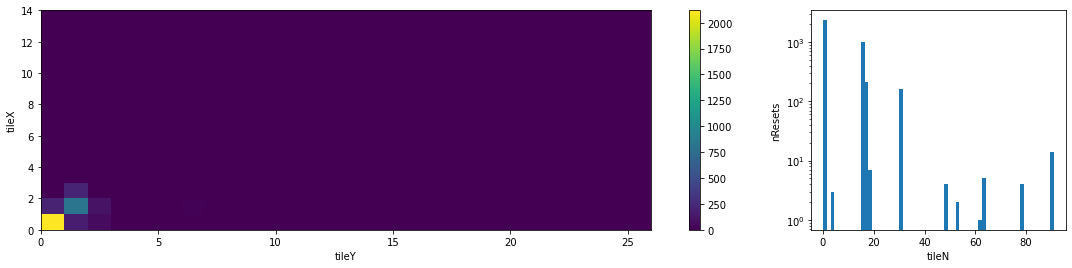

In [11]:
import matplotlib as mpl
scale = 150
# view of tiles
x = df['tileX'].values
y = df['tileY'].values
tileBins = [
    list(range(0, ceil(yMAX/yDIM))),
    list(range(0, ceil(xMAX/xDIM)))
]
fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
h = ax[0].hist2d(y, x, bins=tileBins, range=[[0, ceil(yMAX/yDIM)], [0, ceil(xMAX/xDIM)]])
ax[0].set_ylabel('tileX')
ax[0].set_xlabel("tileY")
fig.colorbar(h[3], ax=ax[0])

nBins = len(yITR) * len(xITR)
tiles = df['tileN'].values
ax[1].hist(tiles, bins=int(np.sqrt(len(tiles))), range=(0,max(tiles)), log=True)
ax[1].set_xlabel('tileN')
ax[1].set_ylabel('nResets')
plt.tight_layout()
plt.savefig("NeutrinoTileHits.pdf")

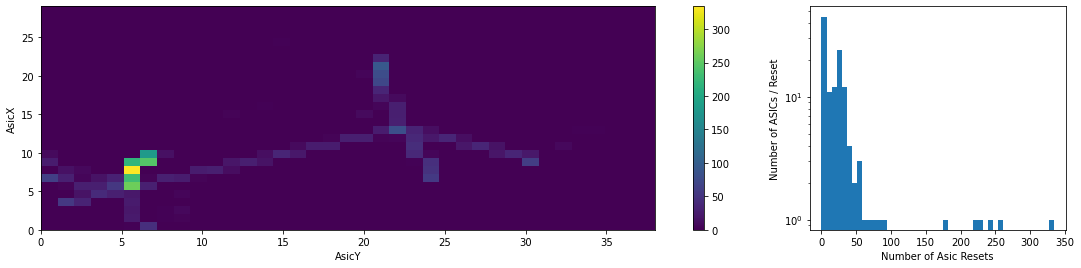

In [12]:
# view of asics
x = df['AsicX'].values
y = df['AsicY'].values

xZoom = 5
yZoom = 10

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

Asics = df['AsicN'].values
nAsics = len(set(df['AsicN'].unique()))

countAsics = df['AsicN'].value_counts()
counts = countAsics.unique()
maxCount = max(counts)
ax[1].hist(countAsics, bins=len(counts), log=True, range=(0, maxCount))
ax[1].set_ylabel("Number of ASICs / Reset")
ax[1].set_xlabel("Number of Asic Resets")
plt.tight_layout()
plt.savefig("NeutrinoAsicHits.pdf")


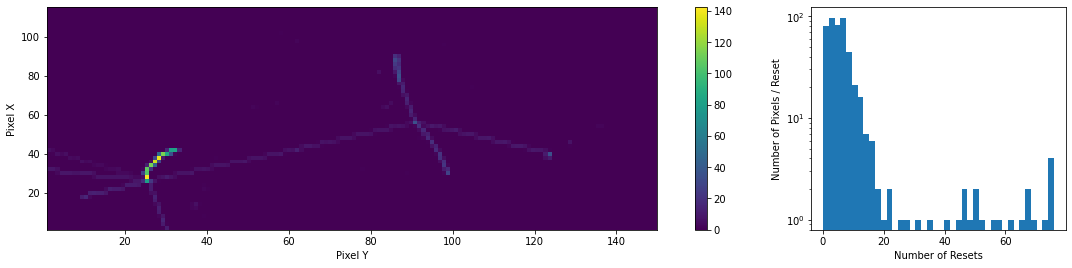

In [13]:
# view of pixels
xZoom = 5
yZoom = 10
x = df['pX'].values
y = df['pY'].values

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
h = ax[0].hist2d(y, x, bins=[int(yMAX/yZoom), int(xMAX/yZoom)], range=[[yMIN,yMAX/yZoom], [xMIN,xMAX/xZoom]])
ax[0].set_ylabel('Pixel X')
ax[0].set_xlabel("Pixel Y")
fig.colorbar(h[3], ax=ax[0])


countPixels = df['PixN'].value_counts()
counts = countPixels.unique()
ax[1] = countPixels.plot.hist(bins=len(counts), range=(0, max(counts)), log=True)
ax[1].set_ylabel("Number of Pixels / Reset")
ax[1].set_xlabel("Number of Resets")
plt.tight_layout()
plt.savefig("NeutrinoPixelHits.pdf")

Found most active tile at (x,y): (1, 1) with 2119 resets.


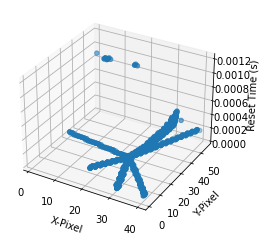

In [14]:
xmin = bestX
xmax = bestX + xDIM
ymin = bestY
ymax = bestY + yDIM

xpos = np.logical_and(npX>=xmin, npX<xmax)
ypos = np.logical_and(npY>=ymin, npY<ymax)
sqpos = np.logical_and(xpos, ypos)

bViewHits = True
if bViewHits:
    ax = plt.axes(projection='3d')
    ax.scatter3D(npX[sqpos], npY[sqpos], npResets[sqpos])
    ax.set_xlabel("X-Pixel")
    ax.set_ylabel("Y-Pixel")
    ax.set_zlabel("Reset Time (s)")
    print(f"Found most active tile at (x,y): ({bestX}, {bestY}) with {len(npX[sqpos])} resets.")

In [15]:
# Pandas filter since all of the data is here, anyways
fdf = df[ (df["pX"] >= bestX) & (df["pX"] < (bestX + xDIM)) & (df["pY"] >= bestY) & (df["pY"] < (bestY + yDIM)) ]

In [16]:
# create the tile's dataframe to send into the QPixAsicArray
tiledf = {}
tiledf["nrows"] = arrayXdim
tiledf["ncols"] = arrayYdim
tiledf["hits"] = []

# normalize asic numbers: this is for the simulation input which "0 numbers" the asic's within it's rows / cols
hitX = fdf["AsicX"].unique()
hitY = fdf["AsicY"].unique()
minX = min(hitX)
minY = min(hitY)

# build the hits tuple for each asic within the tile
for x in hitX:
    for y in hitY:
        asicResets = fdf[ (fdf["AsicX"] == x) & (fdf["AsicY"] == y) ][["Reset","nPix"]].values.tolist()
        arrayX = int(x) if minX == 0 else int(x%minX)
        arrayY = int(y) if minY == 0 else int(y%minY)
        tiledf["hits"].append([arrayX, arrayY, asicResets])

# store the values within a json file
import json
outf = "/mnt/c/Users/keefe/OneDrive/Documents/qpix-digital/simulation-software/tiledf_neut.json"
with open(outf, "w") as outputFile:
    json.dump(tiledf, outputFile, indent=4)

In [17]:
# reading in the json file
import codecs
obj_text = codecs.open(outf, 'r').read()
readDF = json.loads(obj_text)
print(readDF["hits"])

[[0, 7, [[8.033332469527841e-05, 4.0], [8.051332469527832e-05, 4.0], [8.066332469527824e-05, 4.0], [8.080332469527817e-05, 4.0], [8.097332469527808e-05, 4.0], [8.159332469527776e-05, 4.0], [7.986992989741881e-05, 1.0], [7.959671579388861e-05, 5.0], [7.978671579388852e-05, 5.0], [7.995671579388843e-05, 5.0], [8.014671579388833e-05, 5.0], [8.055671579388812e-05, 5.0], [7.869067381280446e-05, 2.0], [7.888067381280436e-05, 2.0], [7.907067381280426e-05, 2.0], [7.931067381280413e-05, 2.0], [7.921643872026336e-05, 6.0], [7.7821996416115e-05, 3.0], [7.80019964161149e-05, 3.0], [7.814199641611483e-05, 3.0], [7.829199641611475e-05, 3.0], [7.845199641611467e-05, 3.0], [7.872199641611453e-05, 3.0]]], [0, 6, []]]
